## Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load in images

In [7]:
gear = cv2.imread("trybik.jpg")
gears = cv2.imread("trybiki2.jpg")

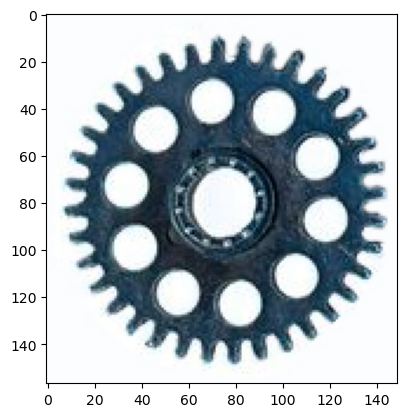

In [8]:
plt.imshow(gear)

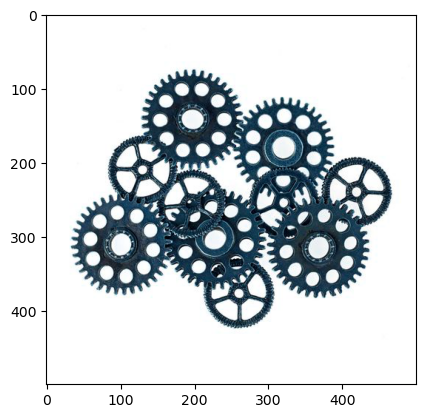

In [9]:
plt.imshow(gears)

## R-Table

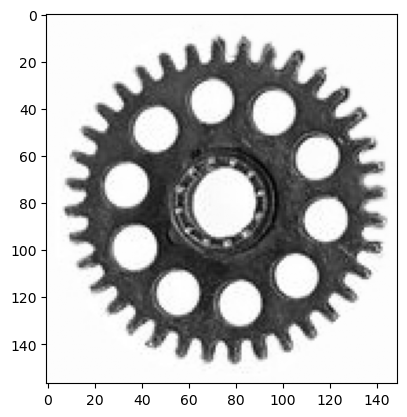

In [12]:
gray_gear = cv2.cvtColor(gear, cv2.COLOR_BGR2GRAY)
plt.gray()
plt.imshow(gray_gear)

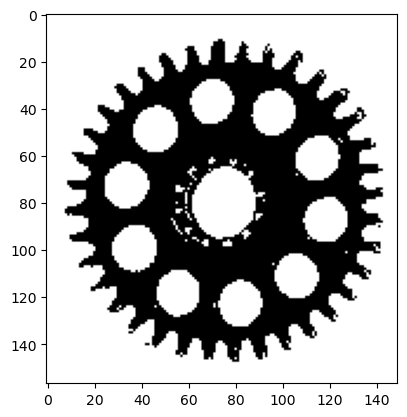

In [18]:
ret, gear_thresh = cv2.threshold(gray_gear, 127, 255, cv2.THRESH_BINARY)

plt.imshow(gear_thresh)

In [19]:
contours, hierarchy = cv2.findContours(gear_thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

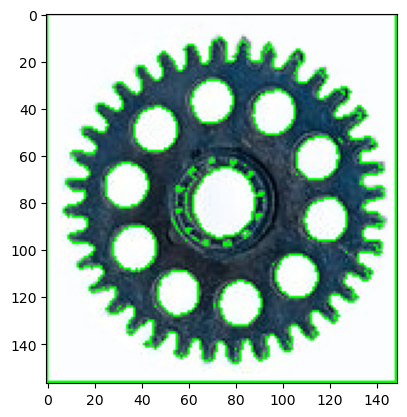

In [23]:
plotted_contours = cv2.drawContours(gear, contours, -1, (0, 255, 0))
plt.imshow(plotted_contours)

In [35]:
gx = cv2.Sobel(gear_thresh, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gear_thresh, cv2.CV_64F, 0, 1, ksize=3)

magnitude, orientation_deg = cv2.cartToPolar(gx, gy, angleInDegrees=True)

In [36]:
M = cv2.moments(gear_thresh, binaryImage=True)

area = M["m00"]

cx = int(M["m10"] / M["m00"])
cy = int(M["m01"] / M["m00"])

In [48]:
r_table = [[] for _ in range(360)]

for cnt in contours:
    for point in cnt:
        x, y = point[0]
        
        phi = int(np.round(orientation_deg[y, x])) % 360
        
        dx = cx - x
        dy = cy - y
        
        r = np.sqrt(dx**2 + dy**2)
        
        alpha = np.degrees(np.arctan2(dy, dx)) % 360
        
        r_table[phi].append((r, alpha))